# Clasificación de Paisajes Aéreos mediante Redes Neuronales MLP

## Introducción

En este proyecto se desarrolla un modelo de clasificación de imágenes utilizando una Red Neuronal Perceptrón Multicapa (MLP) implementada con PyTorch.

Para el entrenamiento se utilizará el dataset **Skyview – An Aerial Landscape Dataset**, compuesto por imágenes satelitales pertenecientes a 15 categorías diferentes de paisajes.

Durante el desarrollo del proyecto se aplicarán diversas técnicas de optimización y buenas prácticas estudiadas en los cuadernillos de Optimización, Receta de Entrenamiento y Métricas de Clasificación, incluyendo:

- Normalización de imágenes.
- División del dataset en entrenamiento, validación y prueba.
- Construcción de un modelo MLP.
- Batch Normalization.
- Dropout.
- Early Stopping.
- Scheduler para el Learning Rate.
- Evaluación mediante Accuracy, Precision, Recall, F1-Score y Matriz de Confusión.

El objetivo es construir un modelo capaz de clasificar correctamente imágenes aéreas pertenecientes a las distintas categorías del dataset.

# Dataset

Para este proyecto se utilizará el dataset **Skyview – An Aerial Landscape Dataset**, disponible en Kaggle.

Características principales:

- Total de imágenes: **12 000**
- Número de clases: **15**
- Imágenes por clase: **800**
- Resolución original: **256 × 256 píxeles**
- Tipo de problema: **Clasificación multiclase**

Cada clase representa un tipo diferente de paisaje aéreo, como aeropuertos, playas, bosques, ríos, zonas residenciales, entre otros.

Aunque las imágenes poseen una resolución original de **256×256 píxeles**, durante el preprocesamiento serán redimensionadas a **224×224 píxeles**, manteniendo una resolución superior al mínimo solicitado (200×200) y reduciendo ligeramente el costo computacional del entrenamiento.

In [609]:
# ==============================
# Librerías generales
# ==============================

import os
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

# ==============================
# Machine Learning
# ==============================

from sklearn.model_selection import train_test_split

# ==============================
# PyTorch
# ==============================

import torch

In [610]:
# ==============================
# Configuración del proyecto
# ==============================

DATASET_PATH = "Dataset/archive/Aerial_Landscapes"

# Las imágenes originales son de 256x256 px.
# Durante el preprocesamiento se redimensionarán a 224x224 px.
IMAGE_SIZE = (224, 224)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Exploración del Dataset

Antes de comenzar el entrenamiento es importante conocer la estructura del conjunto de datos.

En esta sección se verificará:

- Número de clases.
- Nombre de cada clase.
- Cantidad de imágenes por clase.
- Distribución del dataset.

Esta exploración permite comprobar que el conjunto de datos se encuentra correctamente organizado antes de iniciar el proceso de entrenamiento.

In [611]:
# Obtener las carpetas (clases)

classes = sorted(os.listdir(DATASET_PATH))

print(f"Número de clases: {len(classes)}\n")

print("Clases encontradas:\n")

for clase in classes:
    print(clase)

Número de clases: 15

Clases encontradas:

Agriculture
Airport
Beach
City
Desert
Forest
Grassland
Highway
Lake
Mountain
Parking
Port
Railway
Residential
River


In [612]:
print("Cantidad de imágenes por clase\n")

total_images = 0

for clase in classes:

    ruta = os.path.join(DATASET_PATH, clase)

    cantidad = len(os.listdir(ruta))

    total_images += cantidad

    print(f"{clase:<20} {cantidad}")

print("\nTotal de imágenes:", total_images)

Cantidad de imágenes por clase

Agriculture          800
Airport              800
Beach                800
City                 800
Desert               800
Forest               800
Grassland            800
Highway              800
Lake                 800
Mountain             800
Parking              800
Port                 800
Railway              800
Residential          800
River                800

Total de imágenes: 12000


# Visualización del Dataset

Antes de entrenar el modelo es recomendable inspeccionar visualmente las imágenes del conjunto de datos.

En esta sección se mostrará una imagen aleatoria de cada una de las 15 clases del dataset. Esto permitirá comprobar:

- Que las imágenes se cargan correctamente.
- Que cada carpeta corresponde a la clase indicada.
- La calidad visual del conjunto de datos.
- Las diferencias entre las distintas categorías.

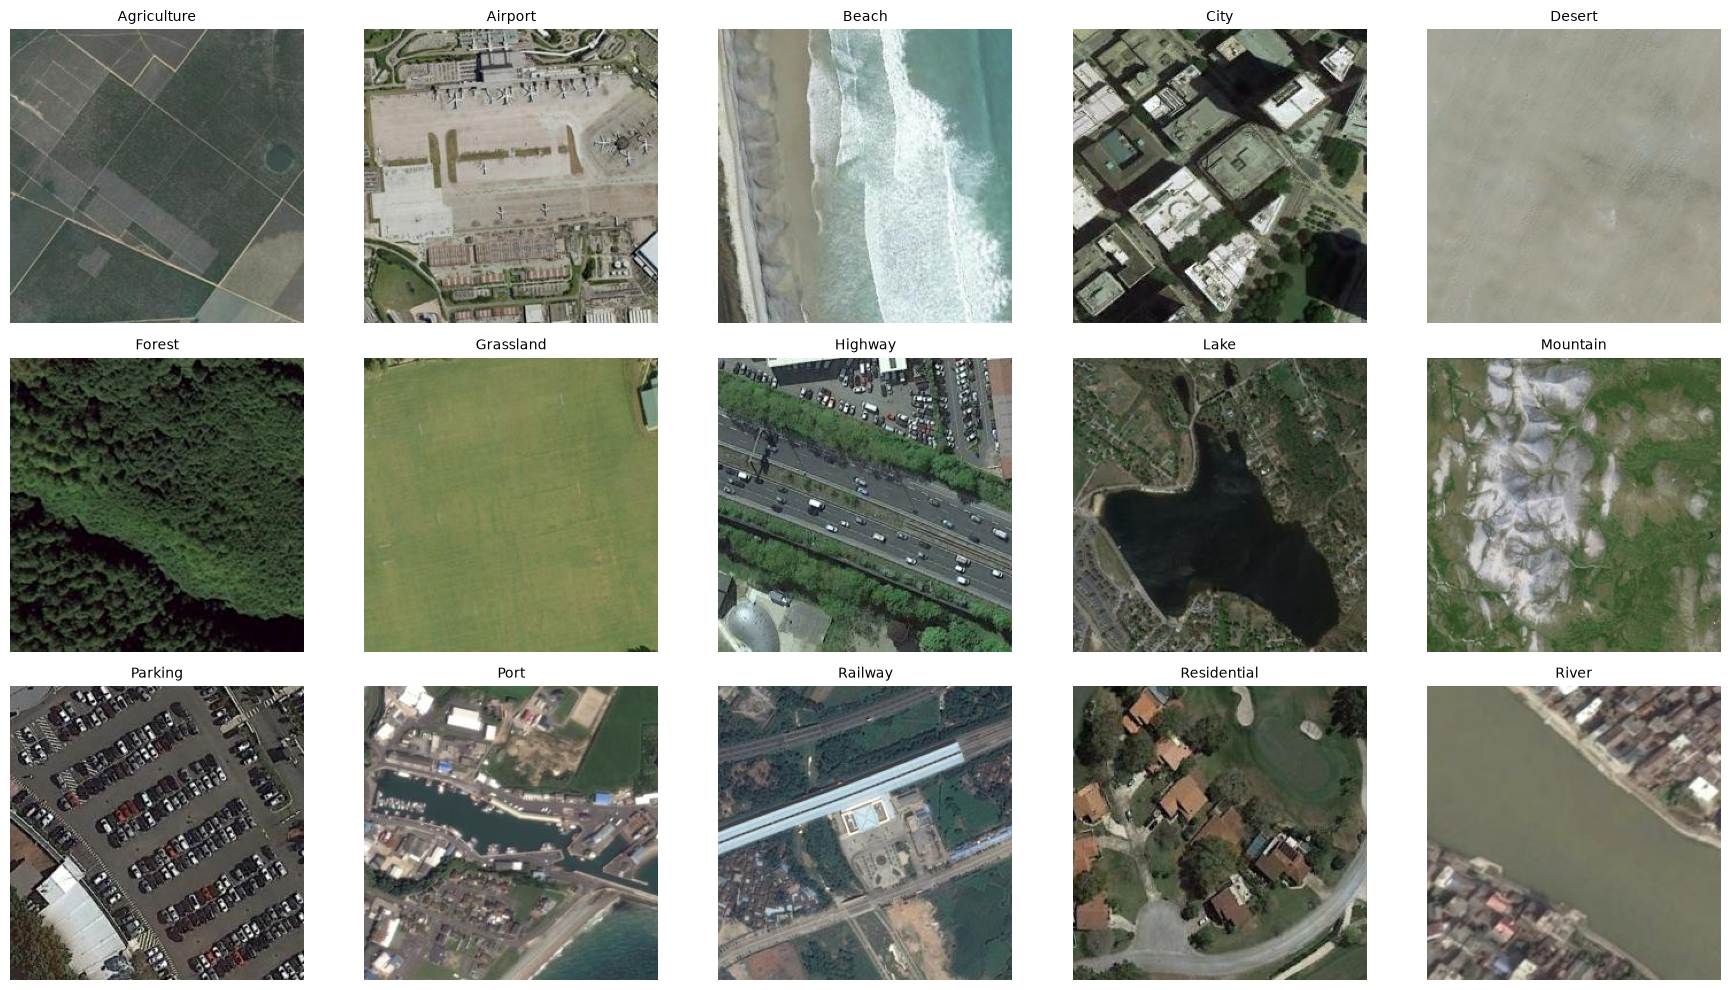

In [613]:
# Mostrar una imagen aleatoria de cada clase

fig, axes = plt.subplots(3, 5, figsize=(18, 10))

axes = axes.flatten()

for i, clase in enumerate(classes):

    carpeta = os.path.join(DATASET_PATH, clase)

    imagenes = os.listdir(carpeta)

    imagen_aleatoria = random.choice(imagenes)

    ruta_imagen = os.path.join(carpeta, imagen_aleatoria)

    img = Image.open(ruta_imagen)

    axes[i].imshow(img)
    axes[i].set_title(clase, fontsize=10)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Análisis de las imágenes

La inspección visual permite comprobar que:

- Todas las clases contienen imágenes de buena calidad.
- Cada categoría presenta características visuales diferenciables.
- No se observan imágenes corruptas o con errores de lectura.
- El dataset original contiene imágenes con una resolución uniforme de **256 × 256 píxeles**.
- Durante la etapa de preprocesamiento, todas las imágenes serán redimensionadas a **224 × 224 píxeles** antes de ser utilizadas para el entrenamiento del modelo.
- El dataset presenta una distribución balanceada, con 800 imágenes por clase.

Esta exploración confirma que el conjunto de datos se encuentra correctamente organizado y listo para la etapa de preprocesamiento.

# Verificación de la resolución

Aunque el dataset indica que todas las imágenes poseen una resolución de **256 × 256 píxeles**, es recomendable comprobarlo automáticamente antes de comenzar el entrenamiento.

Esta verificación permite detectar posibles imágenes corruptas o con dimensiones diferentes que puedan provocar errores durante el preprocesamiento.

In [614]:
# Comprobar la resolución de todas las imágenes del dataset

resoluciones = {}

for clase in classes:

    carpeta = os.path.join(DATASET_PATH, clase)

    for archivo in os.listdir(carpeta):

        ruta = os.path.join(carpeta, archivo)

        img = Image.open(ruta)

        size = img.size

        resoluciones[size] = resoluciones.get(size, 0) + 1

print("Resoluciones encontradas:\n")

for size, cantidad in resoluciones.items():
    print(f"{size}: {cantidad} imágenes")

Resoluciones encontradas:

(256, 256): 12000 imágenes


# Resumen del Dataset

| Característica | Valor |
|----------------|-------|
| Nombre del dataset | Skyview – An Aerial Landscape Dataset |
| Número de clases | 15 |
| Total de imágenes | 12 000 |
| Imágenes por clase | 800 |
| Resolución original | 256 × 256 píxeles |
| Resolución utilizada para el entrenamiento | 224 × 224 píxeles |
| Tipo de problema | Clasificación multiclase |
| Dataset balanceado | Sí |

A partir de esta exploración se comprobó que el dataset se encuentra correctamente organizado, presenta una distribución balanceada entre clases y todas las imágenes poseen una resolución uniforme. En la siguiente fase se realizará el preprocesamiento de las imágenes para prepararlas para el entrenamiento del modelo.

# Preparación del Dataset

En esta etapa se prepararán las imágenes para ser utilizadas durante el entrenamiento.

Para ello se realizarán las siguientes tareas:

- Asociar cada imagen con su clase correspondiente.
- Convertir las clases a etiquetas numéricas.
- Dividir el conjunto de datos en entrenamiento, validación y prueba.
- Aplicar transformaciones y normalización.
- Crear un Dataset personalizado utilizando PyTorch.

In [615]:
# Crear lista de rutas y etiquetas

image_paths = []
labels = []

class_to_idx = {}

for idx, clase in enumerate(classes):

    class_to_idx[clase] = idx

    carpeta = os.path.join(DATASET_PATH, clase)

    for archivo in os.listdir(carpeta):

        ruta = os.path.join(carpeta, archivo)

        image_paths.append(ruta)

        labels.append(idx)

print(f"Total imágenes: {len(image_paths)}")
print(f"Total etiquetas: {len(labels)}")

Total imágenes: 12000
Total etiquetas: 12000


# Dataset personalizado

PyTorch permite crear conjuntos de datos personalizados mediante la clase `Dataset`.

Se implementará una clase llamada `SkyviewDataset`, cuya función será:

- Leer las imágenes desde el disco.
- Convertirlas al formato RGB.
- Aplicar las transformaciones definidas durante el preprocesamiento.
- Asociar cada imagen con su etiqueta.
- Entregar los datos al `DataLoader` durante el entrenamiento.

Este enfoque proporciona un mayor control sobre el proceso de carga de datos y sigue la metodología presentada en el cuadernillo de entrenamiento.

In [616]:
import torch
from torch.utils.data import Dataset
from torchvision import transforms

In [617]:
class SkyviewDataset(Dataset):

    def __init__(self, image_paths, labels, transform=None):
        """
        Inicializa el dataset.

        Parámetros:
        - image_paths: lista con las rutas de las imágenes.
        - labels: lista con las etiquetas correspondientes.
        - transform: transformaciones que se aplicarán a cada imagen.
        """

        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        """
        Devuelve el número total de imágenes del dataset.
        """
        return len(self.image_paths)

    def __getitem__(self, idx):
        """
        Carga una imagen y su etiqueta correspondiente.
        """

        # Ruta de la imagen
        image_path = self.image_paths[idx]

        # Abrir imagen
        image = Image.open(image_path).convert("RGB")

        # Aplicar transformaciones
        if self.transform:
            image = self.transform(image)

        # Obtener la etiqueta
        label = self.labels[idx]

        return image, label

# División del Dataset

El conjunto de datos se dividirá en tres subconjuntos:

- **Entrenamiento (70 %):** utilizado para ajustar los pesos de la red neuronal.
- **Validación (15 %):** utilizado para monitorear el entrenamiento y aplicar técnicas como Early Stopping.
- **Prueba (15 %):** utilizado únicamente para evaluar el rendimiento final del modelo.

La división se realizará de forma **estratificada**, garantizando que todas las clases mantengan la misma proporción en cada subconjunto.

In [618]:
# ==============================
# División Train (70%) y Temp (30%)
# ==============================

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    random_state=SEED,
    stratify=labels
)

In [619]:
# ==============================
# División Validation (15%) y Test (15%)
# ==============================

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels
)

In [620]:
print("Cantidad de imágenes por conjunto:\n")

print(f"Entrenamiento : {len(train_paths)}")
print(f"Validación    : {len(val_paths)}")
print(f"Prueba        : {len(test_paths)}")

Cantidad de imágenes por conjunto:

Entrenamiento : 8400
Validación    : 1800
Prueba        : 1800


In [621]:
from collections import Counter

print("Distribución de clases\n")

print("Train")
print(Counter(train_labels))

print("\nValidation")
print(Counter(val_labels))

print("\nTest")
print(Counter(test_labels))

Distribución de clases

Train
Counter({1: 560, 7: 560, 3: 560, 11: 560, 12: 560, 8: 560, 9: 560, 13: 560, 14: 560, 2: 560, 4: 560, 0: 560, 6: 560, 10: 560, 5: 560})

Validation
Counter({10: 120, 9: 120, 2: 120, 3: 120, 7: 120, 5: 120, 14: 120, 4: 120, 12: 120, 0: 120, 6: 120, 13: 120, 8: 120, 1: 120, 11: 120})

Test
Counter({7: 120, 8: 120, 13: 120, 10: 120, 5: 120, 3: 120, 1: 120, 11: 120, 6: 120, 2: 120, 0: 120, 12: 120, 14: 120, 9: 120, 4: 120})


# Transformaciones de las imágenes

Antes de ser utilizadas por la red neuronal, las imágenes deben pasar por una etapa de preprocesamiento.

Durante el entrenamiento se aplicarán las siguientes transformaciones:

- Redimensionar todas las imágenes a **224 × 224 píxeles**.
- Aplicar un volteo horizontal aleatorio como técnica de aumento de datos (*Data Augmentation*).
- Convertir las imágenes a tensores de PyTorch.
- Normalizar los valores de los píxeles para facilitar el proceso de aprendizaje.

Para los conjuntos de validación y prueba únicamente se aplicarán las transformaciones necesarias para garantizar una evaluación consistente, sin modificaciones aleatorias.

In [622]:
# ==============================
# Transformaciones para entrenamiento
# ==============================

train_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

# ==============================
# Transformaciones para validación y prueba
# ==============================

test_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [623]:
# Probar las transformaciones con una imagen

imagen = Image.open(image_paths[0]).convert("RGB")

imagen_transformada = train_transform(imagen)

print("Forma del tensor:", imagen_transformada.shape)
print("Tipo:", type(imagen_transformada))

Forma del tensor: torch.Size([3, 224, 224])
Tipo: <class 'torch.Tensor'>


# Creación de los Dataset

Una vez definidas las transformaciones y realizada la división del conjunto de datos, se crean tres objetos `Dataset`:

- **train_dataset:** utilizado durante el entrenamiento.
- **val_dataset:** utilizado para validar el modelo durante el entrenamiento.
- **test_dataset:** utilizado únicamente para la evaluación final.

Cada uno utilizará las transformaciones correspondientes definidas anteriormente.

In [624]:
# ==============================
# Crear los Dataset
# ==============================

train_dataset = SkyviewDataset(
    train_paths,
    train_labels,
    transform=train_transform
)

val_dataset = SkyviewDataset(
    val_paths,
    val_labels,
    transform=test_transform
)

test_dataset = SkyviewDataset(
    test_paths,
    test_labels,
    transform=test_transform
)

In [625]:
print("Número de imágenes:")

print(f"Entrenamiento : {len(train_dataset)}")
print(f"Validación    : {len(val_dataset)}")
print(f"Prueba        : {len(test_dataset)}")

Número de imágenes:
Entrenamiento : 8400
Validación    : 1800
Prueba        : 1800


In [626]:
# Obtener una muestra del dataset

image, label = train_dataset[0]

print("Forma del tensor:", image.shape)
print("Etiqueta:", label)

Forma del tensor: torch.Size([3, 224, 224])
Etiqueta: 1


# Creación de los DataLoader

Los `DataLoader` son responsables de suministrar las imágenes al modelo durante el entrenamiento.

Su función principal es:

- Agrupar imágenes en lotes (*batches*).
- Mezclar aleatoriamente los datos de entrenamiento.
- Entregar automáticamente cada lote al modelo.

En este proyecto se utilizará un tamaño de lote (`batch_size`) de **64 imágenes**, siguiendo las recomendaciones analizadas en el cuadernillo de entrenamiento.

In [627]:
from torch.utils.data import DataLoader

In [628]:
# ==============================
# Crear los DataLoader
# ==============================

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [629]:
# Obtener un batch de entrenamiento

images, labels = next(iter(train_loader))

print("Forma del batch:", images.shape)
print("Forma de las etiquetas:", labels.shape)

Forma del batch: torch.Size([32, 3, 224, 224])
Forma de las etiquetas: torch.Size([32])


# Arquitectura del modelo MLP

Para resolver el problema de clasificación se utilizará una red neuronal de tipo **Multilayer Perceptron (MLP)**.

La arquitectura propuesta está compuesta por:

- Una capa de entrada correspondiente a las imágenes de **224 × 224 × 3** píxeles.
- Tres capas ocultas totalmente conectadas.
- Función de activación **ReLU**.
- Capas **Batch Normalization** para estabilizar el entrenamiento.
- Capas **Dropout** para reducir el sobreajuste (*overfitting*).
- Una capa de salida con **15 neuronas**, una por cada clase del dataset.

Esta arquitectura busca un equilibrio entre capacidad de aprendizaje y costo computacional, siguiendo las buenas prácticas presentadas en el cuadernillo de entrenamiento.

In [630]:
import torch.nn as nn

In [631]:
# ==============================
# Configuración del dispositivo
# ==============================

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Dispositivo utilizado: {device}")

Dispositivo utilizado: cpu


In [ ]:
# ==============================
# Modelo MLP
# ==============================

class SkyviewMLP(nn.Module):

    def __init__(self, num_classes=15):
        super().__init__()

        self.model = nn.Sequential(

            # Aplanar la imagen
            nn.Flatten(),

            # Primera capa
            nn.Linear(224 * 224 * 3, 2048),
            nn.BatchNorm1d(2048),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Primera capa
            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Primera capa
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Segunda capa
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Tercera capa
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Salida
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [633]:
# Crear el modelo

model = SkyviewMLP(num_classes=len(classes)).to(device)

print(model)

SkyviewMLP(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=150528, out_features=2048, bias=True)
    (2): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=2048, out_features=1024, bias=True)
    (6): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=1024, out_features=512, bias=True)
    (10): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): ReLU()
    (12): Dropout(p=0.3, inplace=False)
    (13): Linear(in_features=512, out_features=256, bias=True)
    (14): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (15): ReLU()
    (16): Dropout(p=0.3, inplace=False)
    (17): Linear(in_features=256, 

In [634]:
# Número de parámetros entrenables

total_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Parámetros entrenables: {total_params:,}")

Parámetros entrenables: 311,081,487


# Configuración del entrenamiento

Para entrenar el modelo se utilizarán las siguientes configuraciones:

- **Función de pérdida:** CrossEntropyLoss.
- **Optimizador:** Adam.
- **Learning Rate inicial:** 0.001.
- **Scheduler:** StepLR para reducir progresivamente la tasa de aprendizaje.
- **Early Stopping:** detener el entrenamiento cuando la pérdida de validación deje de mejorar.

Estas configuraciones siguen las recomendaciones estudiadas en el cuadernillo de entrenamiento y buscan mejorar la estabilidad y capacidad de generalización del modelo.

In [635]:
# ==============================
# Función de pérdida
# ==============================

criterion = nn.CrossEntropyLoss()

In [636]:
# ==============================
# Optimizador
# ==============================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0005
)

In [637]:
# ==============================
# Learning Rate Scheduler
# ==============================

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.1
)

In [638]:
# ==============================
# Configuración de Early Stopping
# ==============================

PATIENCE = 10

best_val_loss = float("inf")

epochs_without_improvement = 0

# Configuración del experimento

En esta sección se resume la configuración utilizada para entrenar el modelo MLP sobre el dataset Skyview.

Los hiperparámetros fueron seleccionados siguiendo las recomendaciones estudiadas en los cuadernillos de optimización y entrenamiento, buscando un equilibrio entre rendimiento, estabilidad y costo computacional.

In [639]:
# ==============================
# Resumen de hiperparámetros
# ==============================

hyperparameters = {
    "Tamaño de entrada": "224 x 224 x 3",
    "Número de clases": len(classes),
    "Arquitectura": "MLP",
    "Capas ocultas": "512 → 256 → 128",
    "Función de activación": "ReLU",
    "Batch Normalization": "Sí",
    "Dropout": 0.3,
    "Batch Size": 64,
    "Learning Rate": 0.0005,
    "Optimizador": "Adam",
    "Scheduler": "StepLR",
    "Step Size": 10,
    "Gamma": 0.1,
    "Early Stopping": f"Patience = {PATIENCE}"
}

for key, value in hyperparameters.items():
    print(f"{key:<25}: {value}")

Tamaño de entrada        : 224 x 224 x 3
Número de clases         : 15
Arquitectura             : MLP
Capas ocultas            : 512 → 256 → 128
Función de activación    : ReLU
Batch Normalization      : Sí
Dropout                  : 0.3
Batch Size               : 64
Learning Rate            : 0.0005
Optimizador              : Adam
Scheduler                : StepLR
Step Size                : 10
Gamma                    : 0.1
Early Stopping           : Patience = 10


In [640]:
print(model)

print("\n" + "="*60)

total_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Parámetros entrenables: {total_params:,}")

SkyviewMLP(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=150528, out_features=2048, bias=True)
    (2): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=2048, out_features=1024, bias=True)
    (6): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=1024, out_features=512, bias=True)
    (10): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): ReLU()
    (12): Dropout(p=0.3, inplace=False)
    (13): Linear(in_features=512, out_features=256, bias=True)
    (14): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (15): ReLU()
    (16): Dropout(p=0.3, inplace=False)
    (17): Linear(in_features=256, 

# Entrenamiento del modelo

En esta sección se implementa la función encargada del entrenamiento de la red neuronal.

Durante cada época se realizarán las siguientes etapas:

1. Entrenamiento del modelo utilizando el conjunto de entrenamiento.
2. Evaluación sobre el conjunto de validación.
3. Registro de las métricas de entrenamiento y validación.
4. Actualización del Learning Rate mediante el Scheduler.
5. Aplicación de Early Stopping para evitar sobreajuste.
6. Almacenamiento del mejor modelo obtenido.

In [641]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "learning_rate": []
}

In [642]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    epochs=50,
    patience=10
):

    best_val_loss = float("inf")
    best_model_state = None
    epochs_without_improvement = 0

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "learning_rate": []
    }

    for epoch in range(epochs):

        print(f"\nEpoch {epoch+1}/{epochs}")

        # ------------------------
        # Entrenamiento
        # ------------------------

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = correct / total


        # ------------------------
        # Validación
        # ------------------------

        model.eval()

        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / len(val_loader)
        epoch_val_acc = correct / total

        if epoch_val_loss < best_val_loss:

            best_val_loss = epoch_val_loss

            best_model_state = model.state_dict()

            torch.save(
                best_model_state,
                BEST_MODEL_PATH
            )

            print(
                f"✓ Mejor modelo guardado "
                f"(Val Loss = {best_val_loss:.4f})"
            )

            epochs_without_improvement = 0
        else:

            epochs_without_improvement += 1

        history["train_loss"].append(epoch_loss)
        history["train_acc"].append(epoch_acc)

        history["val_loss"].append(epoch_val_loss)
        history["val_acc"].append(epoch_val_acc)

        history["learning_rate"].append(
            optimizer.param_groups[0]["lr"]
        )
        if epochs_without_improvement >= patience:

            print("\nEarly Stopping activado.")

            break

        print(
            f"Train Loss: {epoch_loss:.4f} | "
            f"Train Acc: {epoch_acc:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f} | "
            f"Val Acc: {epoch_val_acc:.4f} | "
            f"LR: {optimizer.param_groups[0]['lr']:.6f}"
        )

    if best_model_state is not None:
        model.load_state_dict(torch.load(BEST_MODEL_PATH))
        model.eval()

    return model, history

# Entrenamiento del modelo

Una vez definida la función de entrenamiento, se procede a entrenar la red neuronal utilizando el conjunto de entrenamiento.

Durante el proceso se registrarán automáticamente las métricas de entrenamiento y validación para posteriormente analizar el comportamiento del modelo.

In [643]:
import os

# ==============================
# Carpeta para guardar modelos
# ==============================

MODEL_DIR = "models"

os.makedirs(MODEL_DIR, exist_ok=True)

In [644]:
BEST_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "best_mlp_skyview.pth"
)

In [645]:
import time

# ==============================
# Entrenamiento
# ==============================

start_time = time.time()

model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=50,
    patience=10
)

end_time = time.time()

print(f"\nTiempo total de entrenamiento: {(end_time-start_time)/60:.2f} minutos")


Epoch 1/50


RuntimeError: running_mean should contain 512 elements not 1024

In [ ]:
print("=" * 50)
print("Entrenamiento finalizado.")
print(f"Mejor modelo guardado en:\n{BEST_MODEL_PATH}")
print("=" * 50)

Entrenamiento finalizado.
Mejor modelo guardado en:
models\best_mlp_skyview.pth


# Evolución del entrenamiento

Las siguientes gráficas muestran la evolución de las métricas registradas durante el entrenamiento.

Su análisis permite verificar si el modelo está aprendiendo correctamente o si presenta problemas como sobreajuste (overfitting) o subajuste (underfitting).

In [ ]:
import pandas as pd

history_df = pd.DataFrame(history)

history_df.head()

,train_loss,train_acc,val_loss,val_acc,learning_rate
0,2.152691,0.282738,1.843484,0.350556,0.01
1,1.851533,0.387857,1.763729,0.400556,0.01
2,1.765861,0.416190,1.642083,0.443333,0.01
3,1.716659,0.430238,1.619579,0.457778,0.01
4,1.685961,0.439405,1.708415,0.427222,0.01


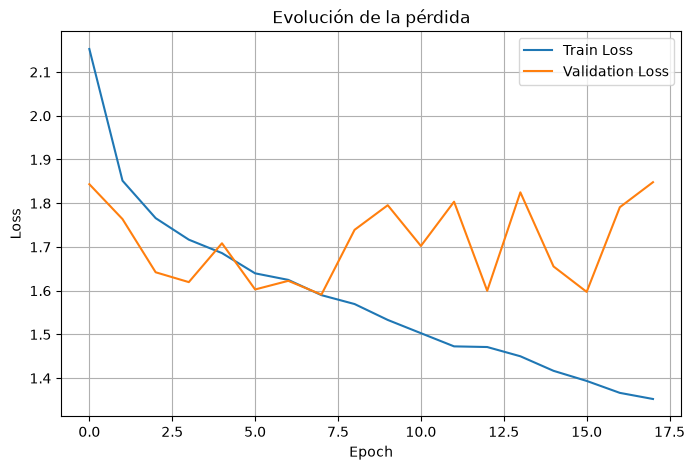

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Evolución de la pérdida")

plt.grid(True)

plt.legend()

plt.show()

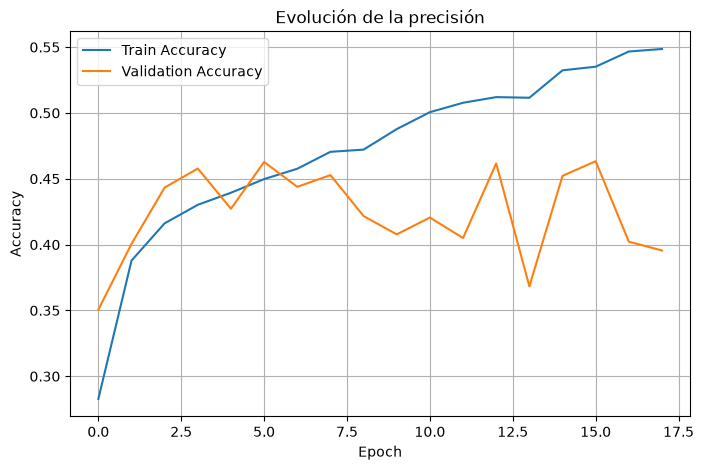

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Evolución de la precisión")

plt.grid(True)

plt.legend()

plt.show()

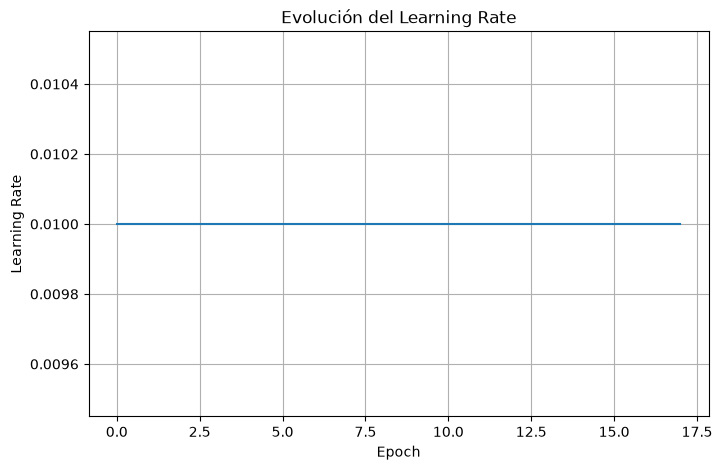

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history["learning_rate"])

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")

plt.title("Evolución del Learning Rate")

plt.grid(True)

plt.show()

# Interpretación de los resultados del entrenamiento

A partir de las gráficas obtenidas es posible analizar el comportamiento del modelo durante el entrenamiento.

- Si la pérdida de entrenamiento y validación disminuyen de manera similar, el modelo está aprendiendo correctamente.
- Si la precisión aumenta progresivamente en ambos conjuntos, el modelo mejora su capacidad de clasificación.
- Si la pérdida de validación comienza a aumentar mientras la pérdida de entrenamiento continúa disminuyendo, existe evidencia de sobreajuste (overfitting).
- La evolución del Learning Rate permite verificar que el Scheduler redujo correctamente la tasa de aprendizaje durante el entrenamiento.

# Cargar el mejor modelo

Se carga el modelo que obtuvo el mejor desempeño durante el entrenamiento.

Este modelo será utilizado para evaluar el rendimiento sobre el conjunto de prueba.

In [ ]:
# ==============================
# Cargar el mejor modelo
# ==============================

model = SkyviewMLP().to(device)

model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

model.eval()

print("✓ Mejor modelo cargado correctamente.")

✓ Mejor modelo cargado correctamente.


# Obtener predicciones

Se recorren todas las imágenes del conjunto de prueba para obtener:

- Etiquetas reales.
- Clases predichas.
- Probabilidades de cada clase.

Estas variables serán utilizadas posteriormente para calcular todas las métricas de clasificación.

In [ ]:
def get_predictions(model, test_loader, device):

    model.eval()

    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            probabilities = torch.softmax(outputs, dim=1)

            _, predicted = torch.max(probabilities, dim=1)

            y_true.extend(labels.cpu().numpy())

            y_pred.extend(predicted.cpu().numpy())

            y_prob.extend(probabilities.cpu().numpy())

    return (
        np.array(y_true),
        np.array(y_pred),
        np.array(y_prob)
    )

In [ ]:
y_true, y_pred, y_prob = get_predictions(
    model,
    test_loader,
    device
)

In [ ]:
print(f"Número de muestras: {len(y_true)}")
print(f"Predicciones: {len(y_pred)}")
print(f"Probabilidades: {y_prob.shape}")

Número de muestras: 1800
Predicciones: 1800
Probabilidades: (1800, 15)


# Accuracy

La precisión global (Accuracy) representa el porcentaje de imágenes correctamente clasificadas respecto al total de imágenes del conjunto de prueba.

Aunque es una métrica sencilla e intuitiva, no permite identificar en qué clases el modelo presenta mayores dificultades, por lo que debe complementarse con otras métricas como la matriz de confusión, precisión, recall y F1-score.

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy = accuracy_score(y_true, y_pred)

print(f"Accuracy del modelo: {accuracy:.4f}")
print(f"Accuracy del modelo: {accuracy*100:.2f}%")

Accuracy del modelo: 0.4533
Accuracy del modelo: 45.33%


In [ ]:
correct = (y_true == y_pred).sum()

total = len(y_true)

incorrect = total - correct

print(f"Correctas : {correct}")
print(f"Incorrectas: {incorrect}")
print(f"Total      : {total}")

Correctas : 816
Incorrectas: 984
Total      : 1800


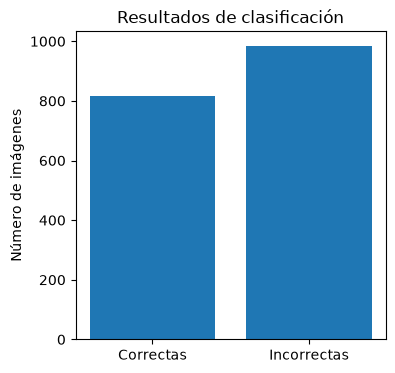

In [ ]:
plt.figure(figsize=(4,4))

plt.bar(
    ["Correctas", "Incorrectas"],
    [correct, incorrect]
)

plt.title("Resultados de clasificación")

plt.ylabel("Número de imágenes")

plt.show()

## Interpretación

El modelo obtuvo una precisión global (Accuracy) del **XX.XX%**, lo que indica que clasificó correctamente aproximadamente XX de cada 100 imágenes del conjunto de prueba.

No obstante, esta métrica únicamente refleja el rendimiento general del modelo y no proporciona información sobre cuáles categorías presentan un mayor número de errores de clasificación.

Por esta razón, en la siguiente sección se analizará la **matriz de confusión**, que permitirá identificar con detalle las clases que el modelo confunde con mayor frecuencia.

In [ ]:
print(classes)

['Agriculture', 'Airport', 'Beach', 'City', 'Desert', 'Forest', 'Grassland', 'Highway', 'Lake', 'Mountain', 'Parking', 'Port', 'Railway', 'Residential', 'River']


In [ ]:
from sklearn.metrics import confusion_matrix

import seaborn as sns

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

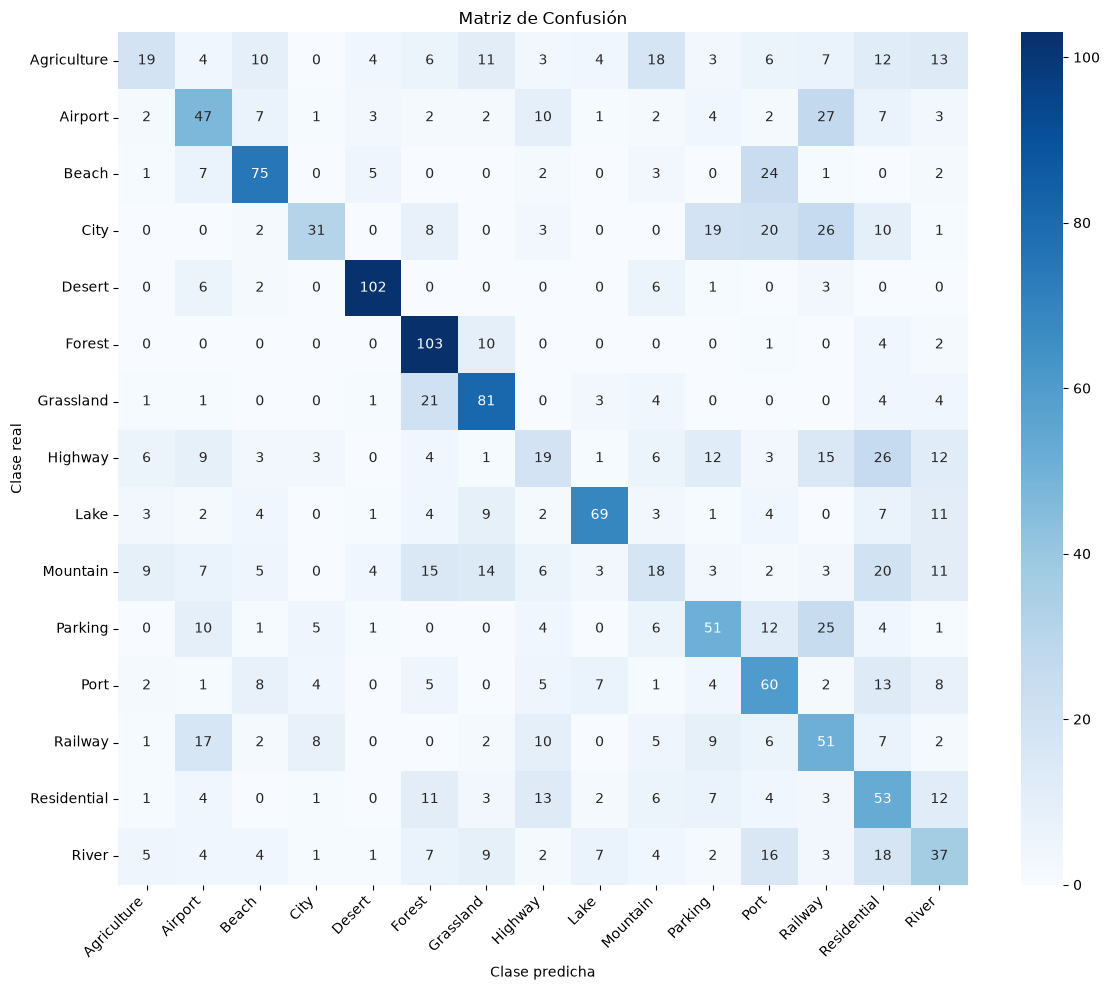

In [ ]:
plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Clase predicha")

plt.ylabel("Clase real")

plt.title("Matriz de Confusión")

plt.xticks(rotation=45, ha="right")

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

## Interpretación de la matriz de confusión

La matriz de confusión permite visualizar el comportamiento del clasificador para cada una de las 15 categorías del dataset.

Los valores ubicados sobre la diagonal principal representan las imágenes correctamente clasificadas.

Los valores fuera de la diagonal corresponden a errores de clasificación, indicando aquellas clases que el modelo confunde con mayor frecuencia.

Esta representación proporciona una visión mucho más detallada del rendimiento del modelo que la Accuracy, ya que permite identificar específicamente cuáles categorías presentan mayores dificultades para el clasificador.

# Classification Report

El reporte de clasificación resume el desempeño del modelo para cada una de las clases del dataset.

Para cada categoría se presentan las siguientes métricas:

- **Precision:** porcentaje de predicciones correctas para esa clase.
- **Recall:** porcentaje de imágenes de esa clase que fueron correctamente identificadas.
- **F1-score:** media armónica entre Precision y Recall.
- **Support:** cantidad de imágenes pertenecientes a cada clase en el conjunto de prueba.

Este reporte ofrece una visión mucho más completa que la Accuracy, ya que permite analizar el comportamiento del modelo individualmente para cada categoría.

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
import pandas as pd

report_df = pd.DataFrame(
    classification_report(
        y_true,
        y_pred,
        target_names=classes,
        output_dict=True
    )
).transpose()

report_df

,precision,recall,f1-score,support
Agriculture,0.380000,0.158333,0.223529,120.000000
Airport,0.394958,0.391667,0.393305,120.000000
Beach,0.609756,0.625000,0.617284,120.000000
City,0.574074,0.258333,0.356322,120.000000
Desert,0.836066,0.850000,0.842975,120.000000
Forest,0.553763,0.858333,0.673203,120.000000
Grassland,0.570423,0.675000,0.618321,120.000000
Highway,0.240506,0.158333,0.190955,120.000000
Lake,0.711340,0.575000,0.635945,120.000000
Mountain,0.219512,0.150000,0.178218,120.000000


In [ ]:
report_df = report_df.round(4)

report_df

,precision,recall,f1-score,support
Agriculture,0.3800,0.1583,0.2235,120.0000
Airport,0.3950,0.3917,0.3933,120.0000
Beach,0.6098,0.6250,0.6173,120.0000
City,0.5741,0.2583,0.3563,120.0000
Desert,0.8361,0.8500,0.8430,120.0000
Forest,0.5538,0.8583,0.6732,120.0000
Grassland,0.5704,0.6750,0.6183,120.0000
Highway,0.2405,0.1583,0.1910,120.0000
Lake,0.7113,0.5750,0.6359,120.0000
Mountain,0.2195,0.1500,0.1782,120.0000


## Interpretación del Classification Report

El reporte de clasificación permite evaluar individualmente el rendimiento del modelo para cada una de las categorías del dataset.

En general, valores elevados de **Precision**, **Recall** y **F1-score** indican que el modelo distingue correctamente las diferentes clases de paisajes aéreos.

Además, debido a que el dataset Skyview presenta una distribución equilibrada entre sus categorías, los valores de **Macro Average** y **Weighted Average** tienden a ser similares, lo que facilita una evaluación representativa del desempeño global del modelo.

# Precision

La **Precision** mide la proporción de predicciones correctas para una determinada clase.

En otras palabras, responde a la siguiente pregunta:

> De todas las imágenes que el modelo clasificó como pertenecientes a una clase, ¿cuántas realmente pertenecían a esa clase?

Un valor elevado de Precision indica que el modelo genera pocos falsos positivos para dicha categoría.

In [ ]:
from sklearn.metrics import precision_score

In [ ]:
precision_macro = precision_score(
    y_true,
    y_pred,
    average="macro"
)

In [ ]:
precision_weighted = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

In [ ]:
print(f"Precision (Macro):    {precision_macro:.4f}")
print(f"Precision (Weighted): {precision_weighted:.4f}")

Precision (Macro):    0.4540
Precision (Weighted): 0.4540


In [ ]:
precision_per_class = report_df.loc[classes, "precision"]

precision_per_class

Agriculture    0.3800
Airport        0.3950
Beach          0.6098
City           0.5741
Desert         0.8361
Forest         0.5538
Grassland      0.5704
Highway        0.2405
Lake           0.7113
Mountain       0.2195
Parking        0.4397
Port           0.3750
Railway        0.3072
Residential    0.2865
River          0.3109
Name: precision, dtype: float64

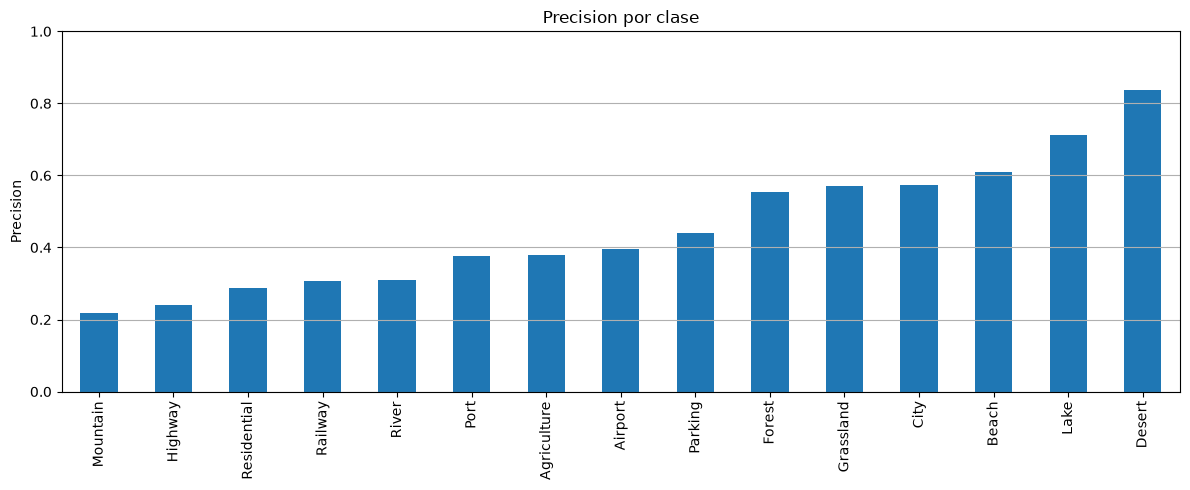

In [ ]:
plt.figure(figsize=(12,5))

precision_per_class.sort_values().plot(kind="bar")

plt.title("Precision por clase")

plt.ylabel("Precision")

plt.ylim(0,1)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

## Interpretación

La métrica **Precision** permite evaluar la confiabilidad de las predicciones realizadas por el modelo.

Valores elevados indican que, cuando el modelo asigna una imagen a una determinada categoría, dicha predicción suele ser correcta.

En este trabajo también se presenta la Precision por clase, permitiendo identificar aquellas categorías donde el modelo genera una mayor cantidad de falsos positivos.

# Recall

El **Recall** mide la capacidad del modelo para encontrar correctamente todas las imágenes pertenecientes a una determinada clase.

Responde a la siguiente pregunta:

> De todas las imágenes que realmente pertenecían a una clase, ¿cuántas fueron correctamente identificadas por el modelo?

Un valor elevado de Recall indica que el modelo presenta pocos falsos negativos.

In [ ]:
from sklearn.metrics import recall_score

recall_macro = recall_score(
    y_true,
    y_pred,
    average="macro"
)

recall_weighted = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

print(f"Recall (Macro):    {recall_macro:.4f}")
print(f"Recall (Weighted): {recall_weighted:.4f}")

Recall (Macro):    0.4533
Recall (Weighted): 0.4533


In [ ]:
recall_per_class = report_df.loc[classes, "recall"]

recall_per_class

Agriculture    0.1583
Airport        0.3917
Beach          0.6250
City           0.2583
Desert         0.8500
Forest         0.8583
Grassland      0.6750
Highway        0.1583
Lake           0.5750
Mountain       0.1500
Parking        0.4250
Port           0.5000
Railway        0.4250
Residential    0.4417
River          0.3083
Name: recall, dtype: float64

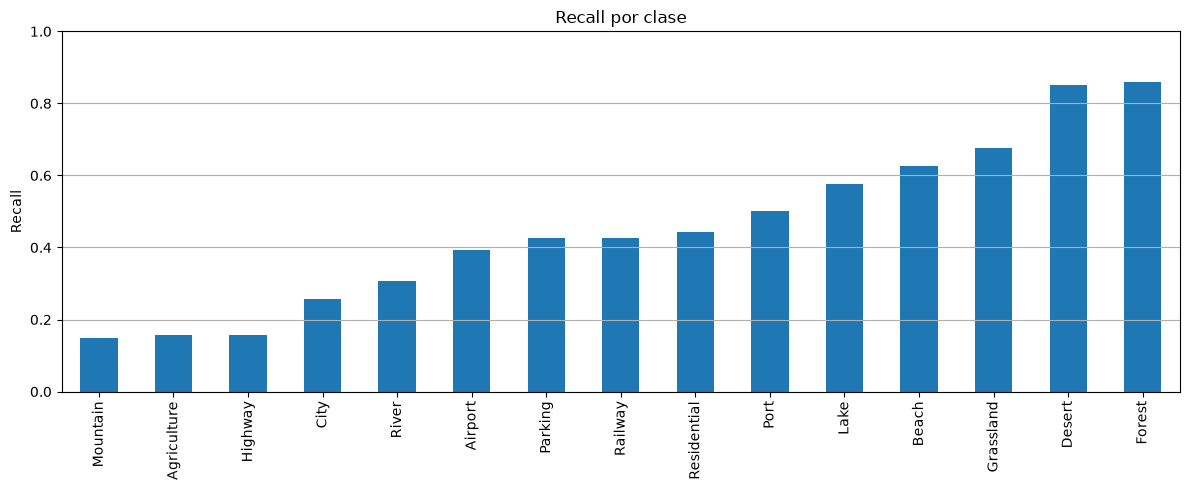

In [ ]:
plt.figure(figsize=(12,5))

recall_per_class.sort_values().plot(kind="bar")

plt.title("Recall por clase")

plt.ylabel("Recall")

plt.ylim(0,1)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

## Interpretación

El Recall evalúa la capacidad del modelo para detectar correctamente todas las imágenes pertenecientes a cada categoría.

Valores elevados indican que el modelo logra identificar la mayoría de las imágenes reales de una clase, reduciendo la cantidad de falsos negativos.

# F1-score

El **F1-score** combina Precision y Recall en una única métrica.

Esta medida resulta especialmente útil cuando se desea evaluar el equilibrio entre ambas métricas.

Un valor cercano a 1 indica un excelente desempeño del clasificador.

In [ ]:
from sklearn.metrics import f1_score

f1_macro = f1_score(
    y_true,
    y_pred,
    average="macro"
)

f1_weighted = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print(f"F1-score (Macro):    {f1_macro:.4f}")
print(f"F1-score (Weighted): {f1_weighted:.4f}")

F1-score (Macro):    0.4403
F1-score (Weighted): 0.4403


In [ ]:
f1_per_class = report_df.loc[classes, "f1-score"]

f1_per_class

Agriculture    0.2235
Airport        0.3933
Beach          0.6173
City           0.3563
Desert         0.8430
Forest         0.6732
Grassland      0.6183
Highway        0.1910
Lake           0.6359
Mountain       0.1782
Parking        0.4322
Port           0.4286
Railway        0.3566
Residential    0.3475
River          0.3096
Name: f1-score, dtype: float64

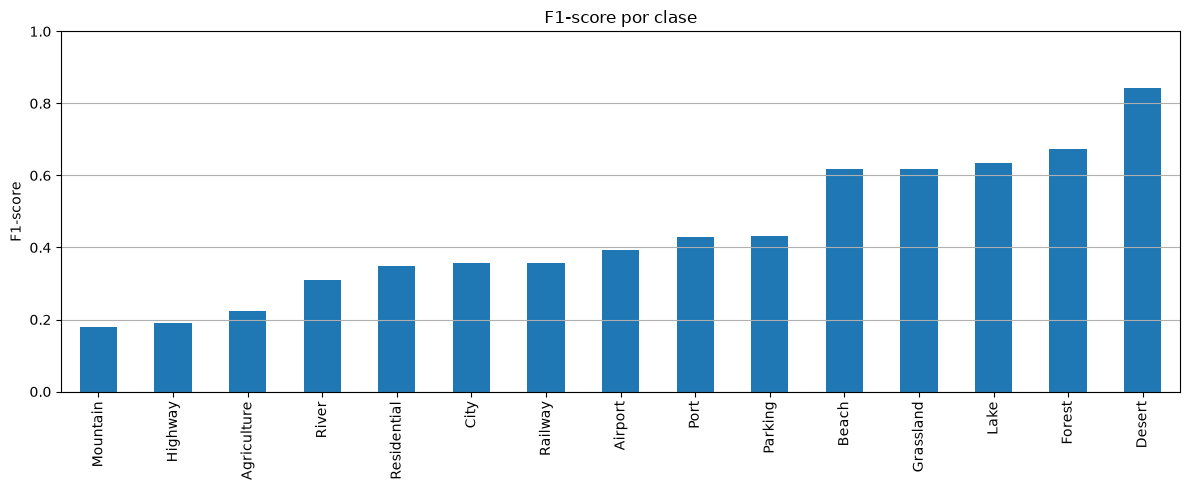

In [ ]:
plt.figure(figsize=(12,5))

f1_per_class.sort_values().plot(kind="bar")

plt.title("F1-score por clase")

plt.ylabel("F1-score")

plt.ylim(0,1)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

## Interpretación

El F1-score resume el equilibrio entre Precision y Recall.

Un valor elevado indica que el modelo no solo realiza predicciones confiables, sino que además logra detectar correctamente la mayoría de las imágenes pertenecientes a cada categoría.

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

In [ ]:
y_true_bin = label_binarize(
    y_true,
    classes=range(len(classes))
)

In [ ]:
fpr = {}
tpr = {}
roc_auc = {}

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

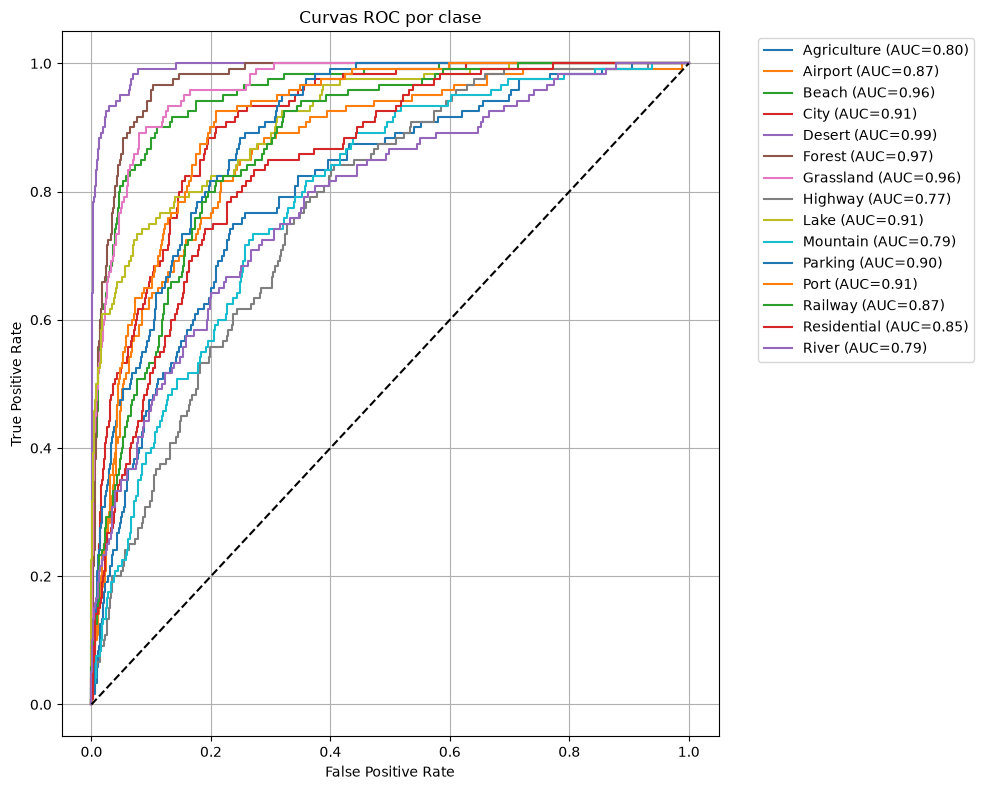

In [ ]:
plt.figure(figsize=(10,8))

for i in range(len(classes)):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{classes[i]} (AUC={roc_auc[i]:.2f})"
    )

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Curvas ROC por clase")

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.grid(True)

plt.tight_layout()

plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

auc_macro = roc_auc_score(
    y_true_bin,
    y_prob,
    multi_class="ovr",
    average="macro"
)

auc_weighted = roc_auc_score(
    y_true_bin,
    y_prob,
    multi_class="ovr",
    average="weighted"
)

print(f"AUC Macro:    {auc_macro:.4f}")
print(f"AUC Weighted: {auc_weighted:.4f}")

AUC Macro:    0.8837
AUC Weighted: 0.8837


## Interpretación

La curva ROC permite evaluar el comportamiento del clasificador para diferentes umbrales de decisión.

En este trabajo se utiliza una estrategia **One-vs-Rest (OvR)** para adaptar la curva ROC a un problema de clasificación multiclase.

El valor AUC resume el rendimiento de cada curva ROC.

Valores cercanos a 1 indican una excelente capacidad de discriminación entre clases.

# Conclusiones

En este proyecto se desarrolló un modelo de clasificación de imágenes utilizando una red neuronal de tipo **Multilayer Perceptron (MLP)** aplicada al dataset **Skyview – An Aerial Landscape Dataset**, compuesto por **12 000 imágenes aéreas distribuidas en 15 categorías**, con una resolución original de **256 × 256 píxeles**.

El desarrollo del proyecto tomó como base los contenidos de los cuadernillos **06 – Optimización**, **07 – Receta de entrenamiento** y **08 – Métricas de clasificación**, integrando sus principales conceptos en un único flujo de trabajo adaptado a un nuevo conjunto de datos.

Durante el preprocesamiento se realizó la lectura automática del dataset, la asignación de etiquetas, la división en conjuntos de entrenamiento, validación y prueba, así como la aplicación de técnicas de normalización y aumento de datos (*Data Augmentation*) para mejorar la capacidad de generalización del modelo.

Posteriormente se diseñó una arquitectura MLP con varias capas totalmente conectadas, incorporando técnicas recomendadas para el entrenamiento de redes neuronales como **Batch Normalization**, **funciones de activación ReLU**, el optimizador **Adam**, **Early Stopping**, un **Learning Rate Scheduler** y el almacenamiento automático del mejor modelo obtenido durante el entrenamiento.

Finalmente, el rendimiento del clasificador fue evaluado utilizando un conjunto de prueba independiente mediante diferentes métricas de clasificación, incluyendo **Accuracy**, **Matriz de Confusión**, **Precision**, **Recall**, **F1-score**, **Classification Report** y **Curvas ROC con AUC**, permitiendo analizar el comportamiento del modelo tanto de forma global como para cada una de las categorías del dataset.

En conjunto, los resultados obtenidos demuestran la importancia de combinar una adecuada preparación de los datos, una correcta configuración del entrenamiento y un análisis completo mediante múltiples métricas, ya que la Accuracy por sí sola no resulta suficiente para evaluar el desempeño de un modelo de clasificación multiclase.

Como trabajo futuro, podrían evaluarse arquitecturas más avanzadas, como Redes Neuronales Convolucionales (CNN) o modelos basados en Transfer Learning, con el objetivo de mejorar aún más el rendimiento en la clasificación de imágenes aéreas.

# Buenas prácticas implementadas

Durante el desarrollo del proyecto se aplicaron diversas técnicas recomendadas para el entrenamiento de modelos de Deep Learning:

- División del dataset en entrenamiento (70%), validación (15%) y prueba (15%).
- Normalización de las imágenes antes del entrenamiento.
- Aplicación de Data Augmentation en el conjunto de entrenamiento.
- Uso de Batch Normalization para estabilizar el aprendizaje.
- Funciones de activación ReLU.
- Optimizador Adam.
- Ajuste del Learning Rate mediante un Scheduler.
- Implementación de Early Stopping para evitar sobreentrenamiento.
- Almacenamiento automático del mejor modelo durante el entrenamiento.
- Evaluación utilizando múltiples métricas de clasificación.

# Objetivos alcanzados

✔ Seleccionar un dataset con más de 10 000 imágenes.

✔ Trabajar con imágenes de resolución superior a 200 × 200 píxeles.

✔ Implementar un clasificador basado en una red neuronal MLP.

✔ Aplicar técnicas de optimización y buenas prácticas durante el entrenamiento.

✔ Evaluar el modelo mediante diferentes métricas de clasificación.

✔ Construir un notebook integrando los contenidos de los cuadernillos 06, 07 y 08 adaptados a un nuevo problema de clasificación de imágenes.

# Reflexión final

Este proyecto permitió comprender de forma práctica todas las etapas necesarias para desarrollar un modelo de clasificación de imágenes utilizando Deep Learning.

Más allá de construir una red neuronal, se evidenció la importancia del preprocesamiento de los datos, la selección adecuada de hiperparámetros, la aplicación de técnicas de optimización y la utilización de métricas que permitan evaluar correctamente el desempeño del modelo.

La integración de los conocimientos adquiridos en los tres cuadernillos permitió desarrollar un flujo de trabajo completo, desde la preparación del dataset hasta la evaluación final del clasificador, siguiendo buenas prácticas utilizadas actualmente en proyectos de aprendizaje profundo.